In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, silhouette_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score
from eval import notation 
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split

In [3]:
# 🔹 Load Dataset
data_1 = pd.read_csv("./data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data_2 = pd.read_csv("./data/2023-02-12.csv")

# 🔹 Normalize column names (remove spaces and lowercase)
data_1.columns = data_1.columns.str.replace(" ", "").str.lower()
data_2.columns = data_2.columns.str.replace(" ", "").str.lower()

# 🔹 Find common columns
common_columns = list(set(data_1.columns) & set(data_2.columns))

# 🔹 Keep only common columns
data_1 = data_1[common_columns]
data_2 = data_2[common_columns]

# 🔹 Concatenate both datasets
concatenated_data = pd.concat([data_1, data_2], ignore_index=True)


# 🔹 Identify Non-Numeric Columns
non_numeric_columns = concatenated_data.select_dtypes(exclude=[np.number]).columns.tolist()
print("⚠️ Non-numeric columns:", non_numeric_columns)

# 🔹 Drop Non-Numeric Columns (Except 'label')
non_numeric_columns = [col for col in non_numeric_columns if col != 'label']
concatenated_data.drop(columns=non_numeric_columns, inplace=True)

# 🔹 Handle Inf and NaN
concatenated_data.replace([np.inf, -np.inf], np.nan, inplace=True)  # Convert inf to NaN
concatenated_data.fillna(concatenated_data.mean(numeric_only=True), inplace=True)  # Replace NaN with column mean

# 🔹 Ensure All Values Are Numeric
for col in concatenated_data.columns:
    if col != 'label':  # ✅ Don't convert the label column!
        concatenated_data[col] = pd.to_numeric(concatenated_data[col], errors='coerce')


⚠️ Non-numeric columns: ['label']


In [4]:
# 🔹 Separate Features and Labels
features = [col for col in concatenated_data.columns if col != 'label']
X = concatenated_data[features]
y = concatenated_data['label']

# 🔹 Convert Labels into Binary (Attack vs. Benign)
y_binary = np.where(y == "BENIGN", 0, 1)  # 0 = BENIGN, 1 = Attack

# 🔹 Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 Split Data
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

print("✅ Data Preprocessing Completed Successfully!")

print("Unique values in 'label' column:", concatenated_data['label'].unique())
print("Label distribution:\n", concatenated_data['label'].value_counts())

✅ Data Preprocessing Completed Successfully!
Unique values in 'label' column: ['BENIGN' 'DDoS' 'adbhoney' 'ddospot' 'log4pot' 'cowrie' 'ciscoasa'
 'redispot' 'elasticpot' 'mailoney']
Label distribution:
 label
DDoS          128027
BENIGN         97718
ddospot        72287
cowrie          2106
log4pot         1388
ciscoasa         195
adbhoney         180
elasticpot        63
mailoney          49
redispot          35
Name: count, dtype: int64


In [5]:
# 🔹 Cross-Validation Setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_score = 0
best_model = None
scores = list()

for train_idx, val_idx in cv.split(X_train_svm, y_train_svm):
    print("-----------------------------------------------\n")
    X_train_fold, X_val_fold = X_train_svm[train_idx], X_train_svm[val_idx]
    y_train_fold, y_val_fold = y_train_svm[train_idx], y_train_svm[val_idx]
    
    model = SVC(kernel='rbf', probability=True, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    score = model.score(X_val_fold, y_val_fold)
    scores.append(score)

    print(f"Accuracy: {score:.4f}")

    if score > best_score:
        best_score = score
        best_model = model

print(f"Best Cross-Validation Score: {best_score:.4f}")

# 🔹 Evaluate Model with Cross-Validation only on train data
print(f"Cross-Validation Accuracy Scores: {scores}")
print(f"Mean Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# 🔹 Save best model
joblib.dump(best_model, "model/best_svm_model.pkl")
print("✅ Best SVM model saved as 'model/best_svm_model.pkl'")


-----------------------------------------------

Accuracy: 0.9983
-----------------------------------------------

Accuracy: 0.9984
-----------------------------------------------

Accuracy: 0.9981
Best Cross-Validation Score: 0.9984
Cross-Validation Accuracy Scores: [0.9983115238497257, 0.9983736001787799, 0.9980632185335088]
Mean Accuracy: 0.9982 ± 0.0001
✅ Best SVM model saved as 'model/best_svm_model.pkl'


SVM Performance (Attack Detection):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19448
           1       1.00      1.00      1.00     40962

    accuracy                           1.00     60410
   macro avg       1.00      1.00      1.00     60410
weighted avg       1.00      1.00      1.00     60410

SVM Performance on Test Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19448
           1       1.00      1.00      1.00     40962

    accuracy                           1.00     60410
   macro avg       1.00      1.00      1.00     60410
weighted avg       1.00      1.00      1.00     60410

Confusion Matrix:
[[19395    53]
 [   22 40940]]


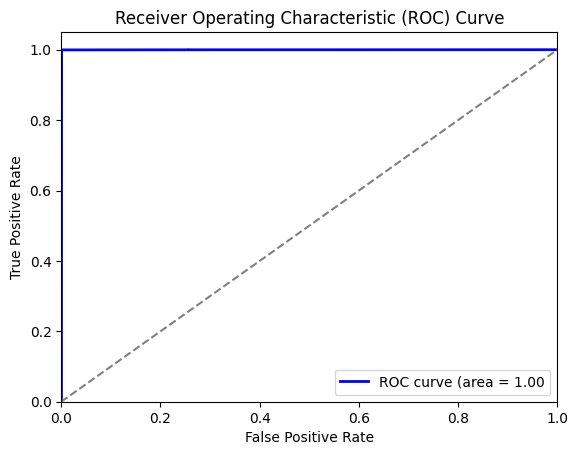

In [6]:
# 🔹 Load best model
best_model = joblib.load("model/best_svm_model.pkl")

# 🔹 Evaluate SVM on test set
y_pred_svm = best_model.predict(X_test_svm)
print("SVM Performance (Attack Detection):")
print(classification_report(y_test_svm, y_pred_svm))

y_pred_proba = best_model.predict_proba(X_test_svm)[:, 1]

print("SVM Performance on Test Data:")
print(classification_report(y_test_svm, y_pred_svm))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_svm, y_pred_svm)
print("Confusion Matrix:")
print(conf_matrix)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_svm, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [7]:
# -------------------- Neural Network for Anomaly Classification -------------------- #

# Filter anomalies
df_anomalies = concatenated_data[concatenated_data['label'] != 'BENIGN']
X_anomalies = df_anomalies[features]
y_anomalies = df_anomalies['label']

# Encode labels
label_encoder = LabelEncoder()
y_anomalies_encoded = label_encoder.fit_transform(y_anomalies)


# Standardization
X_anomalies_scaled = scaler.fit_transform(X_anomalies)

In [8]:
# Afficher la distribution initiale
initial_counts = Counter(y_anomalies_encoded)
print(f"Distribution initiale des labels: {initial_counts}")

# Fixer un nombre cible pour chaque classe
majority_class = max(initial_counts, key=initial_counts.get)
target_size = int(initial_counts[majority_class] * 0.5)  # Réduire la classe majoritaire à 50%

# Stratégie SMOTE : Augmenter les classes minoritaires
smote_strategy = {k: max(v, target_size) for k, v in initial_counts.items() if v < target_size}

# Stratégie Under-sampling : Réduire la classe majoritaire
under_strategy = {majority_class: target_size}

# Pipeline avec SMOTE puis Under-sampling
resampling_pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=smote_strategy, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=under_strategy, random_state=42))
])

# Appliquer le rééquilibrage
X_resampled, y_resampled = resampling_pipeline.fit_resample(X_anomalies_scaled, y_anomalies_encoded)


# Vérifier la nouvelle distribution des labels
print(f"Nouvelle distribution des labels: {Counter(y_resampled)}")

Distribution initiale des labels: Counter({0: 128027, 4: 72287, 3: 2106, 6: 1388, 2: 195, 1: 180, 5: 63, 7: 49, 8: 35})
Nouvelle distribution des labels: Counter({4: 72287, 0: 64013, 1: 64013, 2: 64013, 3: 64013, 5: 64013, 6: 64013, 7: 64013, 8: 64013})


In [14]:
# Vérifier si GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔍 Utilisation de : {device}")

# Split des données
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, random_state=42, stratify=y_resampled
)

# Conversion en tenseurs PyTorch
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_nn, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test_nn, dtype=torch.long).to(device)

# Création des DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Définition du modèle
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Pas de softmax ici, car CrossEntropyLoss l'applique déjà
        return x

# Instancier le modèle
input_size = X_train_nn.shape[1]
num_classes = len(np.unique(y_anomalies_encoded))
model = SimpleNN(input_size, num_classes).to(device)

# Définition de l'optimiseur et de la fonction de perte
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entraînement du modèle
num_epochs = 20
best_loss = float("inf")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    
    train_accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} - Acc: {train_accuracy:.2f}%")
    
    # Sauvegarde du meilleur modèle
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "model/best_nn_model.pth")
        print("✅ Meilleur modèle sauvegardé !")

print("🎯 Entraînement terminé !")

🔍 Utilisation de : cpu
Epoch 1/20 - Loss: 0.6811 - Acc: 73.87%
✅ Meilleur modèle sauvegardé !
Epoch 2/20 - Loss: 0.5588 - Acc: 78.18%
✅ Meilleur modèle sauvegardé !
Epoch 3/20 - Loss: 0.5296 - Acc: 79.45%
✅ Meilleur modèle sauvegardé !
Epoch 4/20 - Loss: 0.5150 - Acc: 80.25%
✅ Meilleur modèle sauvegardé !
Epoch 5/20 - Loss: 0.4990 - Acc: 80.94%
✅ Meilleur modèle sauvegardé !
Epoch 6/20 - Loss: 0.4907 - Acc: 81.23%
✅ Meilleur modèle sauvegardé !
Epoch 7/20 - Loss: 0.4867 - Acc: 81.44%
✅ Meilleur modèle sauvegardé !
Epoch 8/20 - Loss: 0.4779 - Acc: 81.84%
✅ Meilleur modèle sauvegardé !
Epoch 9/20 - Loss: 0.4736 - Acc: 81.97%
✅ Meilleur modèle sauvegardé !
Epoch 10/20 - Loss: 0.4711 - Acc: 82.15%
✅ Meilleur modèle sauvegardé !
Epoch 11/20 - Loss: 0.4640 - Acc: 82.45%
✅ Meilleur modèle sauvegardé !
Epoch 12/20 - Loss: 0.4619 - Acc: 82.52%
✅ Meilleur modèle sauvegardé !
Epoch 13/20 - Loss: 0.4558 - Acc: 82.76%
✅ Meilleur modèle sauvegardé !
Epoch 14/20 - Loss: 0.4582 - Acc: 82.77%
Epoch 15/

In [15]:
# Charger le modèle sauvegardé
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN(input_size, num_classes).to(device)
model.load_state_dict(torch.load("model/best_nn_model.pth"))
model.eval()  # Mettre le modèle en mode évaluation

# Dictionnaire des labels avec leurs noms réels
class_names = {
    0: "DDoS",
    1: "ddospot",
    2: "cowrie",
    3: "log4pot",
    4: "ciscoasa",
    5: "adbhoney",
    6: "elasticpot",
    7: "mailoney",
    8: "redispot"
}

# Prédiction sur les données de test
y_true = []
y_pred = []

with torch.no_grad():  # Pas besoin de calculer les gradients en mode évaluation
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)  # Prendre la classe avec la plus haute probabilité
        
        y_true.extend(y_batch.cpu().numpy())  # Convertir en numpy
        y_pred.extend(predicted.cpu().numpy())

# Évaluation du modèle
accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Précision du modèle : {accuracy:.4f}")

# Conversion des labels numériques en noms
y_true = [class_names[label] for label in y_true]
y_pred = [class_names[label] for label in y_pred]

# Rapport détaillé des performances
print("📊 Rapport de classification :\n")
print(classification_report(y_true, y_pred, digits=4))

✅ Précision du modèle : 0.8563
📊 Rapport de classification :

              precision    recall  f1-score   support

        DDoS     1.0000    0.9998    0.9999     12803
    adbhoney     0.7635    0.8111    0.7866     12803
    ciscoasa     0.9992    0.9998    0.9995     14457
      cowrie     0.8578    0.8500    0.8539     12803
     ddospot     0.7231    0.9206    0.8099     12802
  elasticpot     0.8658    0.6700    0.7554     12802
     log4pot     0.9340    0.8225    0.8747     12803
    mailoney     0.9103    0.8065    0.8552     12803
    redispot     0.7134    0.8081    0.7578     12803

    accuracy                         0.8563    116879
   macro avg     0.8630    0.8543    0.8548    116879
weighted avg     0.8649    0.8563    0.8568    116879

